In [ ]:
Day_38_Ensemple_Techniques_bagging_boosting 
29-apr-25

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
pima_df=pd.read_csv('pima_indians_diabetes.csv')
pima_df.head(3)

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [51]:
x=pima_df.iloc[:,0:8]
x.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [52]:
y=pima_df.iloc[:,8:9]
y.head()

,class
0,1
1,0
2,1
3,0
4,1


In [57]:
from sklearn.model_selection  import train_test_split

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [61]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614, 1), (154, 1))

# 38.1) Bagging - classification models

## 38.1.1) Bagging_classfiler

In [31]:
from sklearn.ensemble import BaggingClassifier #  bagging classifier algorithm
from sklearn.linear_model import LogisticRegression # this is the model which we require to pass to bagging model

- Initialize the model

In [72]:
log_reg_clf=LogisticRegression(max_iter=400)
baggclassifier=BaggingClassifier(estimator=log_reg_clf, n_estimators=100)# estimator=log_reg_clf - need to pass a model which we are going to use in bagging algorithm
# n_estimators=100 - it specifies how many models it will create 

- Train the model

In [75]:
baggclassifier.fit(x_train,y_train)

C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:888: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=LogisticRegression(max_iter=400), n_estimators=100)

- evauate the model for test data

In [178]:
from sklearn.metrics import confusion_matrix,classification_report

In [80]:
y_train_hat=baggclassifier.predict(x_train)

In [82]:
train_cm=confusion_matrix(y_train,y_train_hat)
train_crpt=classification_report(y_train,y_train_hat)

print(train_cm)
print(train_crpt)

[[354  47]
 [ 93 120]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       401
           1       0.72      0.56      0.63       213

    accuracy                           0.77       614
   macro avg       0.76      0.72      0.73       614
weighted avg       0.77      0.77      0.76       614



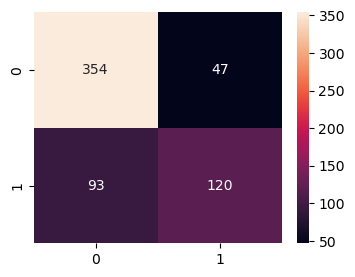

In [84]:
plt.figure(figsize=(4,3))
sns.heatmap(train_cm,annot=True,fmt='d')
plt.show()

- evauate the model for test data

In [87]:
y_hat_test=baggclassifier.predict(x_test)

In [89]:
test_cm=confusion_matrix(y_test,y_hat_test)
test_crpt=classification_report(y_test,y_hat_test)

print(test_cm)
print(test_crpt)

[[78 21]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



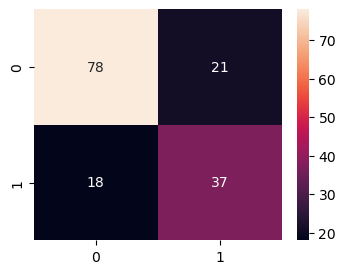

In [91]:
plt.figure(figsize=(4,3))
sns.heatmap(test_cm,annot=True)
plt.show()

## 38.1.2) Random forest

In [96]:
from sklearn.ensemble import RandomForestClassifier

- Initialize the model

In [102]:
rf_clf=RandomForestClassifier(n_estimators=100,max_depth=8)
# estimator - 	While creating random forest we no need to mention any base model as it is going to use Decision tree by default. 


- Train the model

In [106]:
rf_clf.fit(x_train,y_train)

C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=8)

- evaluate the  model with training data

In [109]:
y_hat_train=rf_clf.predict(x_train)

In [120]:
rf_train_cm=confusion_matrix(y_train,y_hat_train)
rf_train_clf_rpt=classification_report(y_train,y_hat_train)
print(rf_train_cm)
print(rf_train_clf_rpt)

[[400   1]
 [ 14 199]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       401
           1       0.99      0.93      0.96       213

    accuracy                           0.98       614
   macro avg       0.98      0.97      0.97       614
weighted avg       0.98      0.98      0.98       614



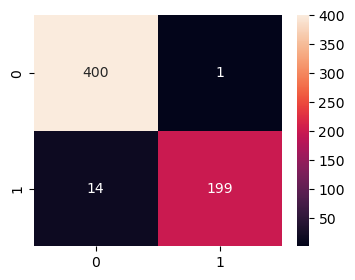

In [122]:
plt.figure(figsize=(4,3))
sns.heatmap(rf_train_cm,annot=True,fmt='d')
plt.show()

- evaluate the  model with training data

In [117]:
y_hat_test=rf_clf.predict(y_test)

In [124]:
rf_test_cm=confusion_matrix(y_test,y_hat_test)
rf_test_clf_rpt=classification_report(y_test,y_hat_test)
print(rf_test_cm)
print(rf_test_clf_rpt)

[[80 19]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



- Overfitting the model as it is doing very good with training data but not that much good with testing data 

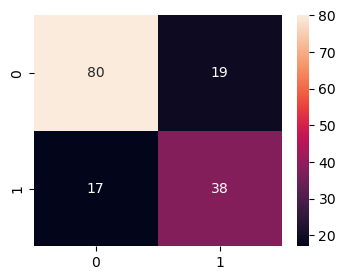

In [126]:
plt.figure(figsize=(4,3))
sns.heatmap(rf_test_cm,annot=True,fmt='d')
plt.show()

# 38.2) Boosting - classification models

## 38.2.1) Adaboost

In [130]:
from sklearn.ensemble import AdaBoostClassifier

In [135]:
ada_clf=AdaBoostClassifier(n_estimators=100)
# in adaboost we can use any base model but default is decision tree

- train the model

In [145]:
ada_clf.fit(x_train,y_train)

C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100)

- evaluyate the model with train data

In [149]:
ada_y_hat_train=ada_clf.predict(x_train)

In [153]:
ada_cm_train=confusion_matrix(y_train,ada_y_hat_train)
ada_clf_rpt_train=classification_report(y_train,ada_y_hat_train)
print(ada_cm_train)
print(ada_clf_rpt_train)

[[365  36]
 [ 50 163]]
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       401
           1       0.82      0.77      0.79       213

    accuracy                           0.86       614
   macro avg       0.85      0.84      0.84       614
weighted avg       0.86      0.86      0.86       614



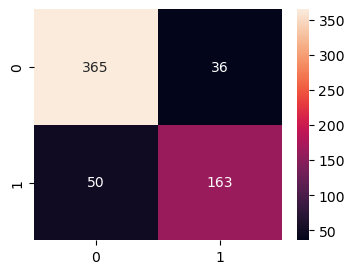

In [155]:
plt.figure(figsize=(4,3))
sns.heatmap(ada_cm_train,annot=True,fmt='d')
plt.show()


- evaluyate the model with test data

In [158]:
ada_y_hat_test=ada_clf.predict(x_test)

In [160]:
ada_cm_test=confusion_matrix(y_test,ada_y_hat_test)
ada_clf_rpt_test=classification_report(y_test,ada_y_hat_test)
print(ada_cm_test)
print(ada_clf_rpt_test)

[[80 19]
 [21 34]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        99
           1       0.64      0.62      0.63        55

    accuracy                           0.74       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



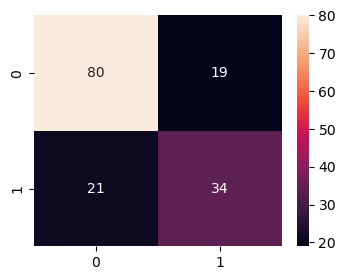

In [162]:
plt.figure(figsize=(4,3))
sns.heatmap(ada_cm_test,annot=True,fmt='d')
plt.show()

# 38.3) Stacking

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
# imported all base models required for stacking
from sklearn.ensemble import VotingClassifier
# imported meta model required for meata model

- Initialize the base models

In [151]:
base_models=[]

In [153]:
log_reg=LogisticRegression(max_iter=200)
base_models.append(('logreg',log_reg))

In [155]:
base_models

[('logreg', LogisticRegression(max_iter=200))]

In [157]:
d_Tree=DecisionTreeClassifier(max_depth=8)
base_models.append(('d_tree',d_Tree))

In [159]:
base_models

[('logreg', LogisticRegression(max_iter=200)),
 ('d_tree', DecisionTreeClassifier(max_depth=8))]

In [161]:
svc = SVC()
base_models.append(('SVC',svc))

In [163]:
base_models

[('logreg', LogisticRegression(max_iter=200)),
 ('d_tree', DecisionTreeClassifier(max_depth=8)),
 ('SVC', SVC())]

- pass theese base models to main stacking(mdeta model)

In [166]:
vot_clf=VotingClassifier(estimators=base_models)

- Train the stacking model

In [169]:
vot_clf.fit(x_train,y_train)

C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


VotingClassifier(estimators=[('logreg', LogisticRegression(max_iter=200)),
                             ('d_tree', DecisionTreeClassifier(max_depth=8)),
                             ('SVC', SVC())])

- Evaluate the model with train

In [174]:
vclf_y_hat_train=vot_clf.predict(x_train)

In [180]:
vclf_cm=confusion_matrix(y_train,vclf_y_hat_train)
vclf_clf_rpt=classification_report(y_train,vclf_y_hat_train)
print(vclf_cm)
print(vclf_clf_rpt)

[[372  29]
 [ 87 126]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       401
           1       0.81      0.59      0.68       213

    accuracy                           0.81       614
   macro avg       0.81      0.76      0.77       614
weighted avg       0.81      0.81      0.80       614



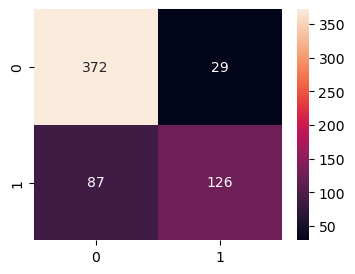

In [182]:
plt.figure(figsize=(4,3))
sns.heatmap(vclf_cm,annot=True,fmt='d')
plt.show()

- Evaluate the model with test

In [187]:
vclf_y_hat_test=vot_clf.predict(x_test)

In [189]:
vclf_cm_test=confusion_matrix(y_test,vclf_y_hat_test)
vclf_clf_rpt_test=classification_report(y_test,vclf_y_hat_test)
print(vclf_cm_test)
print(vclf_clf_rpt_test)

[[83 16]
 [19 36]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



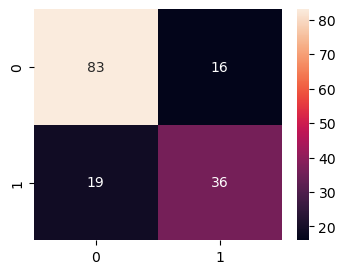

In [192]:
plt.figure(figsize=(4,3))
sns.heatmap(vclf_cm_test,annot=True,fmt='d')
plt.show()

# 38.3) Bagging - Regression models

In [195]:
from sklearn.ensemble import BaggingRegressor #  bagging classifier algorithm
from sklearn.linear_model import LinearRegression # this is the model which we require to pass to bagging model

In [197]:
lin_reg=LinearRegression()

In [199]:
Bag_Reg=BaggingRegressor(estimator=lin_reg)

- Train the model

In [ ]:
Bag_Reg.fit(x_train)